In [1]:
import json
import selfies as sf
from rdkit import Chem as Chem
from rdkit.Chem import Draw
import matplotlib.pyplot as plt
from transformers import AutoTokenizer


/home/chanhui-lee/conda/envs/molca5/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
llm_model = "facebook/galactica-1.3b"
opt_tokenizer = AutoTokenizer.from_pretrained(
    llm_model, use_fast=False, padding_side="right"
)
selfies_token_path = 'model/selfies_dict.txt'

with open(selfies_token_path, "r") as f:
    selfies_tokens = f.readlines()
    selfies_tokens = [token.strip() for token in selfies_tokens]
opt_tokenizer.add_tokens(selfies_tokens)
# get token id of the selfies_tokens
opt_tokenizer.selfies_token_ids = [
    opt_tokenizer(token, add_special_tokens=False).input_ids[0]
    for token in selfies_tokens
]
opt_tokenizer.added_selfies_tokens = selfies_tokens
# remove '.' from the marked list for selfies token
opt_tokenizer.added_selfies_tokens.remove(".")
opt_tokenizer.selfies_token_ids.remove(36)

/home/chanhui-lee/conda/envs/molca5/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [3]:
def gather_taskwise_instance(instances, task):
    task_instances = []
    for instance in instances:
        if instance['task'] == task:
            task_instances.append(instance)
    return task_instances

def get_mol_info(text):
    selfies = text.split('</MOL_1D>')[0].split('<MOL_1D>')[1]
    smiles = sf.decoder(selfies)
    mol = Chem.MolFromSmiles(smiles)
    img = Draw.MolToImage(mol)
    out = {
        'selfies': selfies,
        'smiles': smiles,
        'mol': mol,
        'img': img,
    }
    return out

def draw_plot(instances, idx):
    pred_infos = get_mol_info(instances[idx]['prediction'])
    pred_img = pred_infos['img']
    pred_selfies = pred_infos['selfies']
    pred_selfies_tokens = opt_tokenizer.encode(pred_selfies, add_special_tokens=False)
    
    target_infos = get_mol_info(instances[idx]['target'])
    target_img = target_infos['img']
    target_selfies = target_infos['selfies']
    target_selfies_tokens = opt_tokenizer.encode(target_selfies, add_special_tokens=False)

    token_in_line = 30
    line_space = 20
    height = 400

    # display images in a figure
    fig, axs = plt.subplots(1, 3)
    axs[0].imshow(pred_img)
    axs[0].set_title('Prediction')
    # show textbox of pred_selfies
    axs[0].text(0, height, 'PRED', fontsize=14, color='black')
    height += line_space
    axs[0].text(0, height, f'LENGTH: {len(pred_selfies_tokens)}', fontsize=7, color='black')
    height += line_space

    # print pred_selfies only token_in_line tokens at each line
    for i in range(0, len(pred_selfies_tokens) // token_in_line + 1):
        height += line_space
        one_line = opt_tokenizer.decode(pred_selfies_tokens[i * token_in_line: (i + 1) * token_in_line])
        axs[0].text(0, height, one_line, fontsize=7, color='black')

    axs[1].imshow(target_img)   
    axs[1].set_title('Target')
    # show textbox of target_selfies
    height += 2 * line_space
    axs[0].text(0, height, 'TARGET', fontsize=14, color='black')
    height += line_space
    axs[0].text(0, height, f'LENGTH: {len(target_selfies_tokens)}', fontsize=7, color='black')
    # print target_selfies only token_in_line tokens at each line
    for i in range(0, len(target_selfies_tokens) // token_in_line + 1):
        height += line_space
        one_line = opt_tokenizer.decode(target_selfies_tokens[i * token_in_line: (i + 1) * token_in_line])
        axs[0].text(0, height, one_line, fontsize=7, color='black')



    # remove spine
    for ax in axs:
        ax.axis('off')
    plt.show()

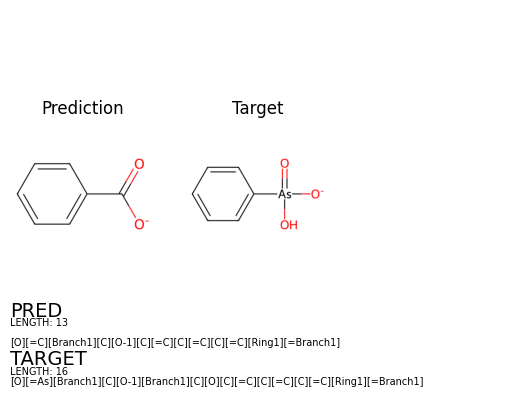

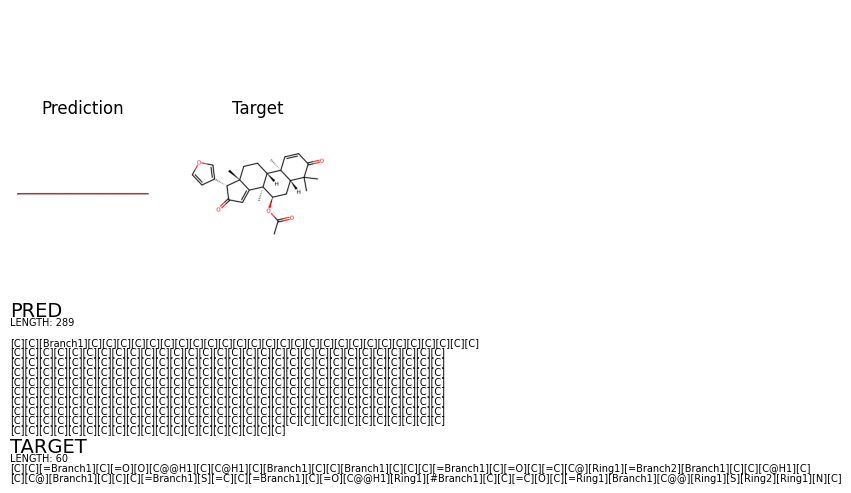

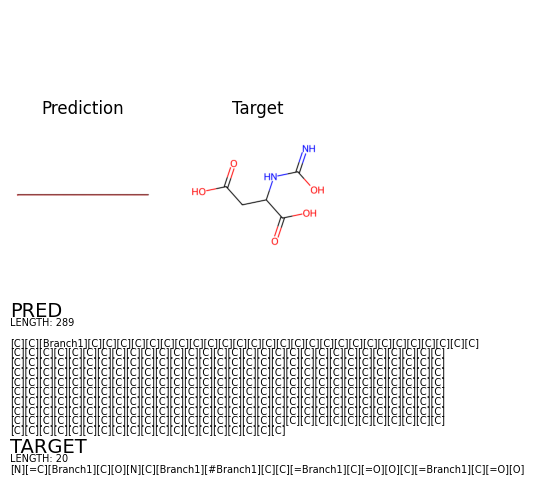

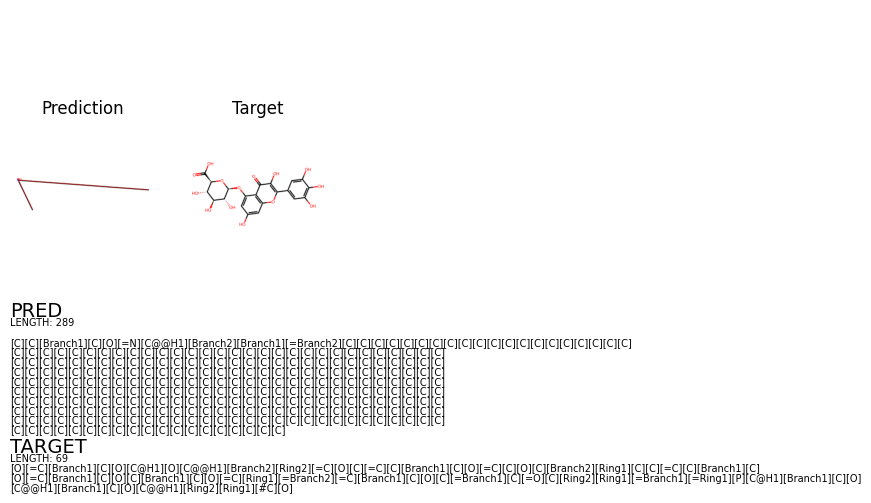

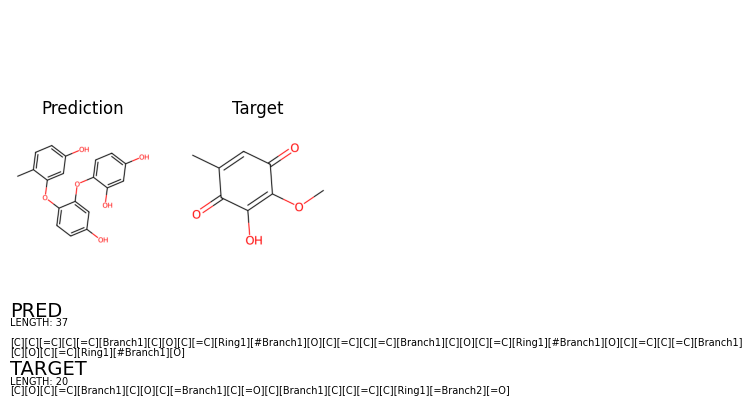

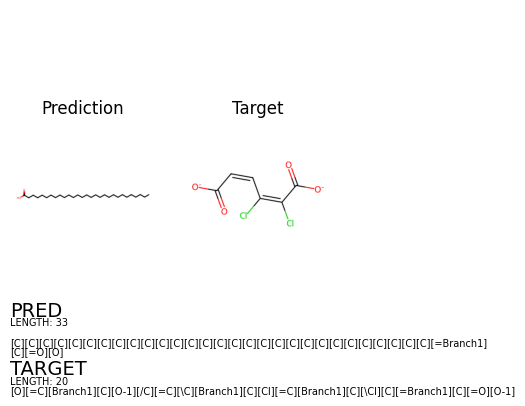

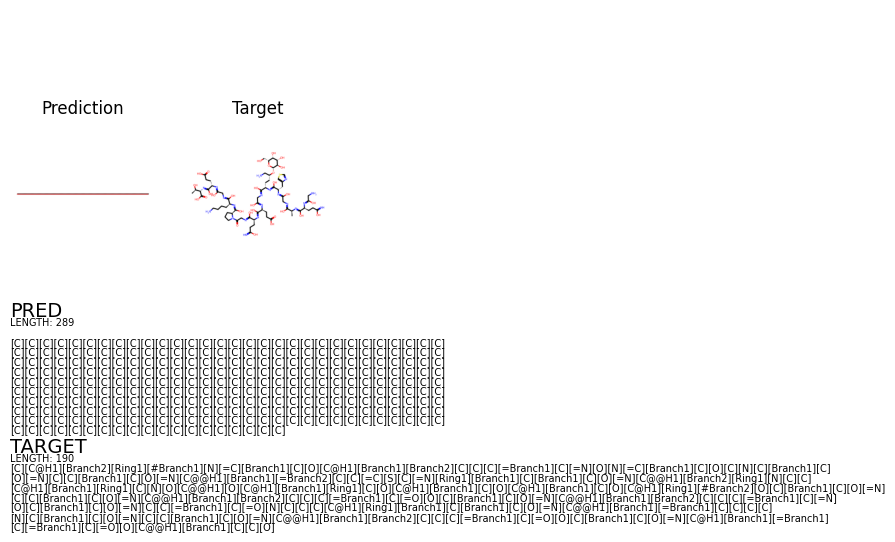

In [5]:
pred_path = 'all_checkpoints/MT_galac1.3b_lorar64_llava1_string+graph_random_replace_0815/lightning_logs/version_1/predictions.json'
# read json file
with open(pred_path, 'r') as f:
    instances = json.load(f)

mol2text = gather_taskwise_instance(instances, 'chebi-20-mol2text/chebi-20-mol2text')
text2mol = gather_taskwise_instance(instances, 'chebi-20-text2mol/chebi-20-text2mol')

num_plot = 5
for i in range(len(text2mol)):
    draw_plot(text2mol, i)
    if i > num_plot:
        break